In [ ]:
!pip install diffusers transformers accelerate insightface onnxruntime opencv-python -q

In [ ]:
import os
import torch

from diffusers import StableDiffusionPipeline

import insightface
import cv2
import numpy as np
import requests

from google.colab import drive

from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model


device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe = pipe.to(device)

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None
)
pipe = pipe.to(device)
MODEL_URL = "https://github.com/deepinsight/insightface/releases/download/v0.7/inswapper_128.onnx"
MODEL_PATH = "/content/inswapper_128.onnx"

if not os.path.exists(MODEL_PATH):
    with requests.get(MODEL_URL, stream=True) as r:
        r.raise_for_status()
        with open(MODEL_PATH, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

face_analyser = FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']
)
face_analyser.prepare(ctx_id=0, det_size=(640, 640))

face_swapper = get_model(MODEL_PATH, providers=['CPUExecutionProvider'])

reference_image_path = "/content/drive/MyDrive/ML8lw/photos/reference.jpg"
print(f"⏳ Чтение эталонного изображения: {reference_image_path}")
ref_img = cv2.imread(reference_image_path)

ref_faces = face_analyser.get(ref_img)

ref_face = ref_faces[0]
print(f"✅ Эталонное лицо извлечено (embedding shape: {ref_face.embedding.shape})")

In [ ]:
def swap_face(target_img_bgr, ref_face):
    target_faces = face_analyser.get(target_img_bgr)

    if not target_faces:
        print("Лицо не детектировано")
        return target_img_bgr

    try:
        result = face_swapper.get(
            target_img_bgr,
            source_face=ref_face,
            target_face=target_faces[0],
            paste_back=True
        )
        return result
    except Exception as e:
        print(f"Ошибка при замене лица: {e}")
        return target_img_bgr

def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

scenarios = [
    "picture of a 20-25 years old male in the forest dressed in boots, black trousers, dark-blue jacket, front view, face clearly visible, looking at camera direction, high quality realism",
    "picture of a 20-25 years old male in an old city dressed in tuxedo, front view, face clearly visible, looking at camera, high quality realism",
    "picture of a 20-25 years old male on a beach dressed in a colorful T-shirt and shorts, front view, face clearly visible, looking at camera, high quality realism",
    "picture of a 20-25 years old male in a cyberpunk style, front view, face clearly visible, looking at camera, high quality realism",
    "picture of a 20-25 years old male made of metal, front view, face clearly visible, looking at camera, high quality realism",
    "picture of a 20-25 years old male standing in a Formula-1 pit lane, front view, face clearly visible, looking at camera, high quality realism"
]

qualifiers = "photorealistic, sharp focus, 8k, detailed skin texture, studio lighting"

generated_images = []
print("Начало генерации изображений.")

for i, scenario in enumerate(scenarios):
    prompt = f"{scenario}, {qualifiers}"
    print(f"  [{i+1}/6] Генерация: {scenario[:50]}...")

    image = pipe(
        prompt=prompt,
        num_inference_steps=50,
        guidance_scale=7.5,
        width=512,
        height=512
    ).images[0]

    img_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    swapped_bgr = swap_face(img_bgr, ref_face)

    generated_images.append(bgr_to_rgb(swapped_bgr))
    print(f"  ✅ Готово: {scenario[:50]}...")

print("Все изображения сгенерированы и обработаны")

Начало генерации изображений.
  [1/6] Генерация: picture of a 20-25 years old male in the forest dr...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✅ Готово: picture of a 20-25 years old male in the forest dr...
  [2/6] Генерация: picture of a 20-25 years old male in an old city d...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✅ Готово: picture of a 20-25 years old male in an old city d...
  [3/6] Генерация: picture of a 20-25 years old male on a beach dress...


...

Лицо не детектировано
  ✅ Готово: picture of a 20-25 years old male in a cyberpunk s...
  [5/6] Генерация: picture of a 20-25 years old male made of metal, f...


  0%|          | 0/50 [00:00<?, ?it/s]

Лицо не детектировано
  ✅ Готово: picture of a 20-25 years old male made of metal, f...
  [6/6] Генерация: picture of a 20-25 years old male standing in a Fo...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✅ Готово: picture of a 20-25 years old male standing in a Fo...
Все изображения сгенерированы и обработаны!


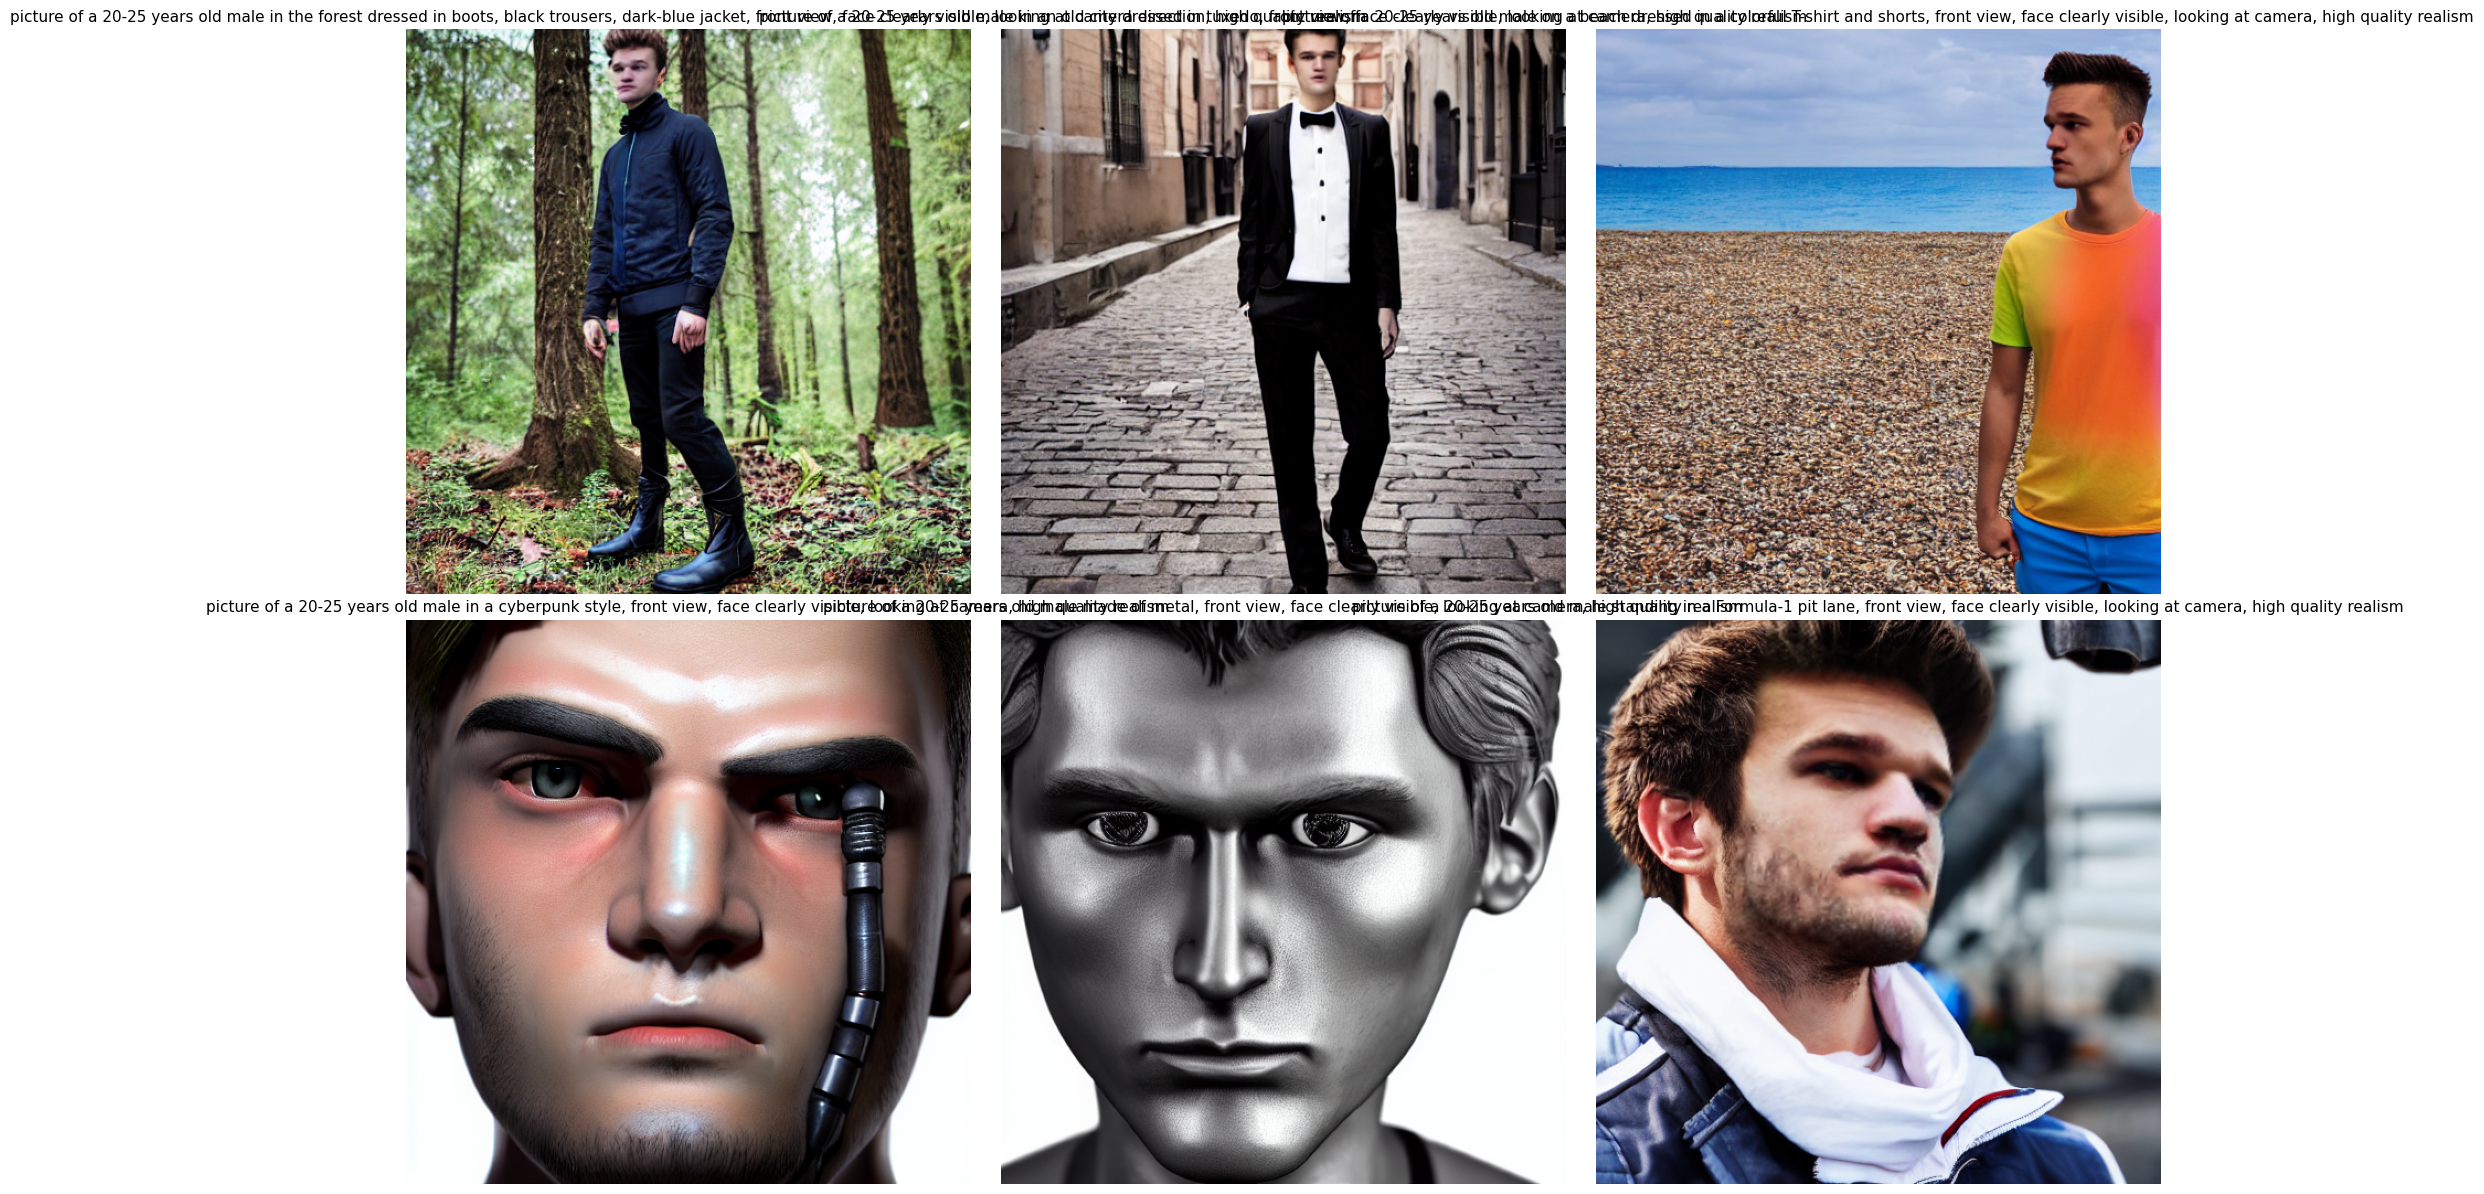

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (img, scenario) in enumerate(zip(generated_images, scenarios)):
    axes[i].imshow(img)
    axes[i].set_title(scenario.replace("A man", "Мужчина"), fontsize=11)
    axes[i].axis('off')

plt.tight_layout()
plt.show()